# Représentations contrastives modernes — du skip-gram aux vues continues

Le notebook [`03-Embeddings-From-Scratch`](../../../GenAI/RAG-et-Memoire-Semantique/03-Embeddings-From-Scratch.ipynb) apprend des embeddings par **cooccurrence discrète** : un mot positif = un mot qui apparaît dans la même fenêtre ; un mot négatif = un mot tiré au hasard dans le vocabulaire. C'est le paradigme **word2vec skip-gram** (Mikolov 2013), et il a fondé l'idée qu'on peut **pré-entraîner sans étiquette**.

Les représentations **contrastives modernes** poussent cette idée plus loin : un exemple positif n'est plus un mot du contexte, c'est **deux vues du même exemple**, produites par des **augmentations** (mask, swap, jitter sur des signaux continus). La loss **InfoNCE** (van den Oord 2018) formalise l'objectif : *rendre la vue positive plus proche de l'original que toute vue négative du mini-lot, à une température donnée*.

> **L'enjeu pédagogique** : on ne va pas charger un SimCLR/CLIP/MoCo pré-entraîné — on va **réécrire** la loss InfoNCE et l'encodeur à la main, **vérifier** sur un mini-lot calculable à la main, puis voir ce que ça donne sur le mini-corpus 7 thèmes de `03-Embeddings`. **Trois graines, trois températures, trois politiques d'augmentation** — et un contre-témoin de **collapse** mesuré (la dégénérescence où l'encodeur produit une constante, le mal silencieux du contrastif).

## Prérequis

Le pré-entraînement se fait **sans étiquette** : les **thèmes** (cuisine, informatique, …) sont utilisés **uniquement à l'évaluation aval** (sonde linéaire + retrieval). Cela reflète la convention SSL (self-supervised learning) où les labels n'interviennent qu'au moment du *downstream task*.

## Bibliothèques

NumPy pour l'encodeur et la loss (from scratch), matplotlib pour les figures, rien d'autre.

## 1. Mini-corpus 7 thèmes — réutilisation du socle skip-gram

On reprend **exactement** le mini-corpus de `03-Embeddings-From-Scratch.ipynb` : 7 thèmes sémantiques, générés par gabarits, **graine fixée** (reproductibilité). Chaque phrase est étiquetée par son thème *uniquement pour l'évaluation aval* — pas pour le pré-entraînement.

In [1]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

rng = np.random.default_rng(42)  # graine globale, reproductibilité

def tokeniser(phrase):
    return [t for t in re.findall(r"[a-zà-ÿœç-]+", phrase.lower()) if len(t) >= 2]

themes = {
    "cuisine":      ["tarte","pommes","fraises","gâteau","chocolat","sucre","citron","fromage",
                     "soupe","cuisine","miel","confiture","brioche","salade","légume","pêche",
                     "abricot","carotte"],
    "informatique": ["ordinateur","programme","algorithme","mémoire","données","serveur",
                     "réseau","calcul","machine","système","logiciel","processeur",
                     "fichier","code","binaire","tableau","boucle","variable"],
    "météo":        ["soleil","pluie","ciel","nuage","tempête","neige","vent","orage","lumière",
                     "chaleur","brouillard","gel","averse","éclair","crachin","giboulée",
                     "zéphyr","grêle"],
    "animaux":      ["chat","chien","oiseau","cheval","renard","souris","fourmi","pré","forêt",
                     "cour","loup","ours","lapin","hibou","nid","écurie","grange","faucon"],
    "transport":    ["train","avion","voiture","gare","aéroport","route","ville","voyage",
                     "tunnel","rivière","quai","rail","vol","billet","périphérie",
                     "carrefour","paquebot","viaduc"],
    "maison":       ["maison","fenêtre","toit","chambre","long","mur","pièce","grange","jardin",
                     "fleur","portail","grenier","cave","escalier","balcon","clôture","haie",
                     "parquet"],
    "émotions":     ["joie","peur","colère","tristesse","surprise","amour","visage","cœur",
                     "sourire","larme","angoisse","haine","espoir","regret","bonheur",
                     "mélancolie","orgueil","douleur"],
    }
THEMES = list(themes.keys())

gabarits = [
    "{a} et {b} vont ensemble", "le {a} ressemble au {b}",
    "un lien unit le {a} et le {b}", "un {a} rappelle un {b}",
    "on associe {a} et {b}", "le {a} comme le {b}",
    "le {a} avec le {b}", "{a} voisine {b} dans la mémoire",
    "{a} et {b} partagent le même {c}", "{a} et {b} sont liés",
    ]

N_PHRASES = 1400
phrases, labels_theme = [], []
for k in range(N_PHRASES):
    theme = THEMES[k % len(THEMES)]
    mots = themes[theme]
    gab = gabarits[k % len(gabarits)]
    a, b = rng.choice(mots, size=2, replace=False)
    phrase = gab.format(a=a, b=b, c=rng.choice(mots))
    phrases.append(phrase)
    labels_theme.append(THEMES.index(theme))
labels_theme = np.array(labels_theme)

vocab = sorted({t for ph in phrases for t in tokeniser(ph)})
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
V = len(vocab)
print(f"vocab: {V} mots, phrases: {len(phrases)}")

vocab: 146 mots, phrases: 1400


Le vocabulaire contient 146 mots uniques pour un total de 1400 phrases, formant ainsi la base lexicale complète nécessaire à la représentation vectorielle des textes du corpus.


## 2. Représentation par sac-de-mots (BoW) — vue continue = vecteur creux

Pour appliquer les **augmentations** au niveau d'un exemple, il faut une représentation **vectorielle continue** de la phrase. On choisit le **sac-de-mots normalisé** (BoW) : un vecteur de taille V avec un 1 par mot présent (lissage TF). C'est notre **signal de base** — la version *continue* de la cooccurrence discrète du skip-gram.

Le pré-entraînement ne verra **jamais** les labels de thème.

In [2]:
def phrase_en_bow(phrase, vocab_size, word2idx):
    v = np.zeros(vocab_size)
    for t in tokeniser(phrase):
        if t in word2idx:
            v[word2idx[t]] += 1.0
    s = v.sum()
    if s > 0:
        v = v / s
    return v

X = np.stack([phrase_en_bow(p, V, word2idx) for p in phrases])  # (N, V)
print(f"X.shape = {X.shape}, mean L1 = {np.abs(X).sum(axis=1).mean():.3f}")

X.shape = (1400, 146), mean L1 = 1.000


**Lecture** : Verbatim : « X.shape = (1400, 146), mean L1 = 1.000 » — chaque phrase est un vecteur BoW **normalisé** (la somme des poids vaut 1 par ligne). La rareté, elle, se lit au compte de composantes non nulles : l'exemple de la cellule de masquage n'en porte que 5 sur 146 (« nnz orig=5 ») — plus de 96 % des dimensions à zéro.

## 3. Augmentations — deux politiques contrôlées + une identité

Pour qu'une vue soit *de la même phrase vue autrement*, on altère le BoW par une politique déterministe à partir d'une **graine par vue** :

- **`mask`** : on met à zéro une fraction `p` des composantes non-nulles (mots dropped).
- **`swap`** : on permute deux composantes non-nulles choisies au hasard (bruit local).
- **`id`** : vue identique (sanity check — pas une vraie augmentation, sert de borne inférieure).

On génère **deux vues positives par phrase**, graines distinctes.

In [3]:
def vue_mask(x, rng, p=0.30):
    """Met à zéro p% des composantes NON-nulles."""
    v = x.copy()
    nz = np.where(v != 0)[0]
    if len(nz) == 0:
        return v
    n_drop = max(1, int(round(p * len(nz))))
    drop = rng.choice(nz, size=n_drop, replace=False)
    v[drop] = 0.0
    s = v.sum()
    if s > 0:
        v = v / s
    return v

def vue_swap(x, rng, p=0.30):
    """Permute aléatoirement p% des composantes non-nulles (bruit local)."""
    v = x.copy()
    nz = np.where(v != 0)[0]
    if len(nz) < 2:
        return v
    n_swap = max(1, int(round(p * len(nz))))
    swap_idx = rng.choice(nz, size=min(2*n_swap, len(nz)), replace=False)
    perm = swap_idx.copy()
    rng.shuffle(perm)
    v[swap_idx] = v[perm]
    return v

def vue_id(x, rng):
    return x.copy()

POLITIQUES = {
    "mask":  (vue_mask,  {"p": 0.30}),
    "swap":  (vue_swap,  {"p": 0.30}),
    "id":    (vue_id,    {}),
    }

# Démo : 3 vues d'une même phrase
rng_demo = np.random.default_rng(0)
x_demo = X[0]
for nom, (fn, kw) in POLITIQUES.items():
    rng_p = np.random.default_rng(1)
    v = fn(x_demo, rng_p, **kw)
    nz_orig = int((x_demo != 0).sum()); nz_vue = int((v != 0).sum())
    cos = float((x_demo @ v) / (np.linalg.norm(x_demo)*np.linalg.norm(v) + 1e-12))
    print(f"  politique={nom:<5} : nnz orig={nz_orig}, nnz vue={nz_vue}, cosinus={cos:.3f}")
# Portee reelle du swap sur tout le corpus (mesure, graine fixee)
rng_mes = np.random.default_rng(0)
n_rep = 0
n_mod = 0
for x in X:
    nz = np.where(x != 0)[0]
    if len(nz) > 0 and x.max() > 1.0 / len(nz) + 1e-9:
        n_rep += 1  # poids non uniformes = au moins un mot repete
    if not np.array_equal(vue_swap(x, rng_mes, p=0.30), x):
        n_mod += 1
print(f"  corpus : {n_rep}/{X.shape[0]} phrases avec un mot repete ; swap modifie {n_mod}/{X.shape[0]} vecteurs")


  politique=mask  : nnz orig=5, nnz vue=3, cosinus=0.775
  politique=swap  : nnz orig=5, nnz vue=5, cosinus=1.000
  politique=id    : nnz orig=5, nnz vue=5, cosinus=1.000
  corpus : 578/1400 phrases avec un mot repete ; swap modifie 163/1400 vecteurs


**Lecture** : verbatim de la démo — « politique=mask : nnz orig=5, nnz vue=3, cosinus=0.775 » : le masquage p=0.30 retire 2 mots sur 5 puis renormalise ; la paire reste un rapprochement à cosinus élevé. Le fait saillant est la ligne swap : « cosinus=1.000 », identique à id. Sur un BoW L1-normalisé, permuter des composantes non-nulles de poids égaux est un no-op exact. La mesure de corpus en fin de cellule le quantifie : seules 578/1400 phrases contiennent un mot répété (poids non uniformes, seules permutables avec effet), et à graine fixée swap ne modifie que 163/1400 vecteurs — sur ~88 % du corpus, la vue swap est strictement identique à l'originale. Conséquence pour la paire d'entraînement par défaut du §6 (politique_b="swap") : côté b, quatre phrases sur cinq n'apportent aucune augmentation — tout le signal de la paire vient alors du masquage côté a.


## 4. Encodeur MLP — from scratch, sans autograd

L'encodeur projette un BoW de taille `V` dans un espace de taille `d` via deux couches linéaires + ReLU. C'est délibérément petit — le contrastif moderne a souvent des encodeurs larges (ResNet-50, ViT), mais on est ici dans un notebook pédagogique où **chaque gradient doit rester lisible**.

On code la **forward** ET la **backward** à la main (NumPy) — pas d'autograd. C'est l'esprit de la série 3.X (cf `3.1-Retropropagation`).

In [4]:
class EncodeurMLP:
    """MLP 2 couches : V -> d (ReLU) -> d (linéaire). L2-normalisé en sortie (cosinus friendly)."""
    def __init__(self, d_in, d_hid, d_out, rng, scale=0.1):
        self.W1 = rng.normal(0, scale, size=(d_in, d_hid)).astype(np.float64)
        self.b1 = np.zeros(d_hid, dtype=np.float64)
        self.W2 = rng.normal(0, scale, size=(d_hid, d_out)).astype(np.float64)
        self.b2 = np.zeros(d_out, dtype=np.float64)

    def forward(self, X, cache=False):
        z1 = X @ self.W1 + self.b1
        h = np.maximum(0, z1)              # ReLU
        z2 = h @ self.W2 + self.b2
        # L2-normalisation par ligne (cosine-friendly)
        n = np.linalg.norm(z2, axis=1, keepdims=True) + 1e-12
        z2 = z2 / n
        if cache:
            return z2, (X, z1, h, n)
        return z2

    def backward(self, grad_out, cache, lr=1e-2):
        """grad_out : (B, d_out) — gradient de la loss par rapport à z2 normalisé."""
        X, z1, h, n = cache
        B = X.shape[0]
        # dérivée de la L2-norm : z2 * grad_out projeté orthogonalement
        # d z2_i / d z2raw_i = (I - z2 z2^T) / n   (par ligne)
        z2raw = h @ self.W2 + self.b2
        proj = grad_out - (z2raw * grad_out).sum(axis=1, keepdims=True) * z2raw / (n**2)
        proj = proj / n
        # gradients couche 2
        gW2 = h.T @ proj
        gb2 = proj.sum(axis=0)
        # backprop dans ReLU + couche 1
        dh = proj @ self.W2.T
        dz1 = dh * (z1 > 0)
        gW1 = X.T @ dz1
        gb1 = dz1.sum(axis=0)
        # SGD
        self.W2 -= lr * gW2; self.b2 -= lr * gb2
        self.W1 -= lr * gW1; self.b1 -= lr * gb1
    
    def params(self):
        return [self.W1, self.b1, self.W2, self.b2]

# Test : la sortie doit être L2-normalisée (||z2_i|| = 1)
enc_test = EncodeurMLP(V, 64, 32, np.random.default_rng(0))
z_test = enc_test.forward(X[:5])
norms = np.linalg.norm(z_test, axis=1)
print(f"||z|| par ligne (doit valoir ~1.0) : {norms}")

||z|| par ligne (doit valoir ~1.0) : [1. 1. 1. 1. 1.]


**Lecture** : verbatim du contrôle — « ||z|| par ligne (doit valoir ~1.0) : [1. 1. 1. 1. 1.] ». La sortie de l'encodeur est L2-normalisée par construction (dernière opération du forward) : le produit scalaire entre deux lignes est donc exactement leur cosinus, ce que la loss InfoNCE du §5 consomme directement.


## 5. Loss InfoNCE — from scratch, vérification mini-lot

InfoNCE (van den Oord 2018) traite la discrimination positive/négative comme une **classification à N classes** (N = taille du mini-lot) : la similarité cosinus entre la vue *a* et la vue positive *b* doit être plus grande que la similarité à toute vue négative du batch, à une température τ donnée.

Formule (symétrique, deux directions) :

    L = (1/2B) * Σ_i [ -log(exp(sim(z_a_i, z_b_i)/τ) / Σ_j exp(sim(z_a_i, z_b_j)/τ))
                          -log(exp(sim(z_b_i, z_a_i)/τ) / Σ_j exp(sim(z_b_i, z_a_j)/τ)) ]

où `sim` est le produit scalaire (les vecteurs sont déjà L2-normalisés → cosinus).

**Vérification mini-lot calculable à la main** : avec B=2, on peut écrire la matrice 2×2 des logits et vérifier que la somme des deux lignes = τ·log(...) attendue.

In [5]:
def loss_infonce(z_a, z_b, tau):
    """InfoNCE symétrique : logits = z_a @ z_b.T / tau. Renvoie (loss, gradient par rapport à z_a, gradient par rapport à z_b)."""
    z_a = np.asarray(z_a, dtype=np.float64)
    z_b = np.asarray(z_b, dtype=np.float64)
    logits = (z_a @ z_b.T) / tau
    # softmax sur chaque ligne
    logits_max = logits.max(axis=1, keepdims=True)
    exp_a = np.exp(logits - logits_max)
    p_a = exp_a / exp_a.sum(axis=1, keepdims=True)
    # cible = colonne i (paire positive)
    target = np.arange(z_a.shape[0])
    loss_a = -np.log(p_a[np.arange(z_a.shape[0]), target] + 1e-12).mean()

    logits_b = (z_b @ z_a.T) / tau
    logits_b_max = logits_b.max(axis=1, keepdims=True)
    exp_b = np.exp(logits_b - logits_b_max)
    p_b = exp_b / exp_b.sum(axis=1, keepdims=True)
    loss_b = -np.log(p_b[np.arange(z_b.shape[0]), target] + 1e-12).mean()
    loss = 0.5 * (loss_a + loss_b)

    # gradients
    grad_a = (p_a - np.eye(z_a.shape[0])) @ z_b / (tau * z_a.shape[0])
    grad_b = (p_b - np.eye(z_b.shape[0])) @ z_a / (tau * z_b.shape[0])
    return float(loss), grad_a, grad_b

# Vérification mini-lot à la main : 3 cas distincts avec valeurs attendues dérivées
# de la formule : loss_sym = 0.5 * (loss_a + loss_b) où chaque loss_* = -log(p[positif]).
# Pour chaque anchor i :
#   - logits diagonal = 1 : p = e/(e+1) -> loss_single = -log(e/(e+1)) ≈ 0.3133
#   - logits uniformes (ambigu parfait) : p = 0.5 -> loss_single = log(2) ≈ 0.6931
# La loss symétrique est 0.5*(loss_a + loss_b) ; dans le cas ambigu avec logits = 0 partout,
# loss_a = loss_b = log(2) -> loss_sym = log(2) ≈ 0.6931 (et NON log(2)/2 qui correspondrait
# à un seul côté de la perte).

tau = 1.0

# CAS 1 : positifs séparés (z_a == z_b, logits = matrice identité diagonale)
# logit positif = 1, négatif = 0 ; p(positif) = e/(e+1) -> perte single ≈ 0.3133
# loss_sym = 0.5 * (0.3133 + 0.3133) = 0.3133 (les deux côtés voient le même pattern diagonal).
z_a_test = np.array([[1.0, 0.0], [0.0, 1.0]])
z_b_test = np.array([[1.0, 0.0], [0.0, 1.0]])
loss_sep, _, _ = loss_infonce(z_a_test, z_b_test, tau)
print(f"CAS 1 (positifs séparés z_a==z_b) : loss = {loss_sep:.4f}, "
      f"attendu = -log(e/(e+1)) = {-np.log(np.e/(np.e+1)):.4f}")

# CAS 2 : orthogonal vrai (z_b est la permutation de z_a : paires positives sur le mauvais axe).
# logits = [[0,1],[1,0]] (anti-diagonale). Pour anchor 0 : logit positif = 0, négatif = 1
# p(positif) = e^0 / (e^0 + e^1) = 1/(1+e) -> perte single = log(1+e) ≈ 1.3133
# Le pattern est symétrique : loss_a = loss_b = log(1+e) -> loss_sym ≈ 1.3133 (PAS log(2)/2).
z_b_perm = np.array([[0.0, 1.0], [1.0, 0.0]])
loss_orth, _, _ = loss_infonce(z_a_test, z_b_perm, tau)
print(f"CAS 2 (orthogonal vrai z_b=perm) : loss = {loss_orth:.4f}, "
      f"attendu = log(1+e) = {np.log(1+np.e):.4f}")

# CAS 3 : ambigu parfait (logits = 0 dans TOUTE la matrice BxB, donc p uniforme = 0.5).
# Pour cela il faut dim > B et que z_a_i et z_b_j soient orthogonaux pour TOUTES les paires (i,j) :
# autrement dit, les supports des deux matrices sont disjoints (z_a vit dans dim 0..1, z_b dans dim 2..3).
# Avec B=2 et dim=4, chaque anchor voit 1 positif + 1 négatif tous deux à produit scalaire nul :
# logits = z_a @ z_b.T = matrice nulle 2x2 -> p = 0.5 -> loss_single = log(2) ≈ 0.6931
# loss_sym = 0.5*(log(2)+log(2)) = log(2) ≈ 0.6931 (et NON log(2)/2).
z_a_amb = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
z_b_amb = np.array([[0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]])
loss_amb, _, _ = loss_infonce(z_a_amb, z_b_amb, tau)
print(f"CAS 3 (ambigu parfait B=2 dim=4, supports disjoints) : loss = {loss_amb:.4f}, "
      f"attendu = log(2) = {np.log(2):.4f} (et NON log(2)/2)")

# Conclusion pédagogique : la perte symétrique est comprise entre
# -log(e/(e+1)) ≈ 0.3133 (CAS 1 : positifs séparés, logit positif=1, négatif=0)
# et  log(1+e) ≈ 1.3133 (CAS 2 : orthogonal vrai, négatif plus grand que positif)
# avec  log(2) ≈ 0.6931 (CAS 3 : ambigu parfait, tous les logits à 0)
# au milieu. Un encodeur aléatoire se situe près de CAS 3 (≈ 0.69), et c'est l'écart
# à log(2) qui mesure l'apprentissage réel.

CAS 1 (positifs séparés z_a==z_b) : loss = 0.3133, attendu = -log(e/(e+1)) = 0.3133
CAS 2 (orthogonal vrai z_b=perm) : loss = 1.3133, attendu = log(1+e) = 1.3133
CAS 3 (ambigu parfait B=2 dim=4, supports disjoints) : loss = 0.6931, attendu = log(2) = 0.6931 (et NON log(2)/2)


**Lecture** : verbatim des trois cas — « CAS 1 (positifs séparés z_a==z_b) : loss = 0.3133, attendu = -log(e/(e+1)) = 0.3133 », « CAS 2 (orthogonal vrai z_b=perm) : loss = 1.3133, attendu = log(1+e) = 1.3133 », « CAS 3 (ambigu parfait B=2 dim=4, supports disjoints) : loss = 0.6931, attendu = log(2) = 0.6931 ». Trois régimes — paires identiques, négatifs orthogonaux, ambiguïté parfaite — trois valeurs imprimées égales à leurs attendus théoriques au chiffre affiché près : l'implémentation symétrique de la loss est vérifiée sur le mini-lot calculable à la main.


## 6. Boucle d'entraînement — pré-entraînement contrastif sans étiquette

Algorithme : pour chaque mini-lot, on tire deux politiques d'augmentation (graines distinctes), on encode les deux vues, on calcule la loss InfoNCE symétrique, on backpropagate dans l'encodeur. **Pas de label de thème n'intervient ici** — l'encodeur apprend à représenter deux vues de la même phrase de manière proche.

In [6]:
def entrainement_contrastif(X, politique_a="mask", politique_b="swap",
                             tau=0.1, n_epochs=8, batch_size=64, lr=1e-2,
                             d_hid=64, d_out=32, graine=0, verbose=True):
    rng = np.random.default_rng(graine)
    enc = EncodeurMLP(X.shape[1], d_hid, d_out, rng)
    fn_a, kw_a = POLITIQUES[politique_a]
    fn_b, kw_b = POLITIQUES[politique_b]
    rng_a = np.random.default_rng(graine + 1000)
    rng_b = np.random.default_rng(graine + 2000)
    rng_batch = np.random.default_rng(graine + 3000)
    N = X.shape[0]
    pertes = []
    for ep in range(n_epochs):
        idx = rng_batch.permutation(N)
        perte_ep = []
        for s in range(0, N, batch_size):
            ib = idx[s:s+batch_size]
            Xb = X[ib]
            Va = np.stack([fn_a(x, rng_a, **kw_a) for x in Xb])
            Vb = np.stack([fn_b(x, rng_b, **kw_b) for x in Xb])
            za, cache_a = enc.forward(Va, cache=True)
            zb, cache_b = enc.forward(Vb, cache=True)
            loss, ga, gb = loss_infonce(za, zb, tau)
            enc.backward(ga, cache_a, lr=lr)
            enc.backward(gb, cache_b, lr=lr)
            perte_ep.append(loss)
        perte_moy = float(np.mean(perte_ep))
        pertes.append(perte_moy)
        if verbose:
            print(f"  époque {ep+1:>2} : loss={perte_moy:.4f}")
    return enc, pertes

print("Entraînement principal : mask vs swap, τ=0.1, 8 époques, graine 0")
print("=" * 60)
enc_main, pertes_main = entrainement_contrastif(X, politique_a="mask", politique_b="swap",
                                                 tau=0.1, n_epochs=8, batch_size=64, lr=1e-2,
                                                 d_hid=64, d_out=32, graine=0)
print(f"\nLoss finale : {pertes_main[-1]:.4f}, log(64) = {math.log(64):.4f} (borne sup = log(batch))")

Entraînement principal : mask vs swap, τ=0.1, 8 époques, graine 0
  époque  1 : loss=1.3217


  époque  2 : loss=1.0388
  époque  3 : loss=0.9079


  époque  4 : loss=0.7024


  époque  5 : loss=0.7460
  époque  6 : loss=0.6697


  époque  7 : loss=0.5788
  époque  8 : loss=0.5975

Loss finale : 0.5975, log(64) = 4.1589 (borne sup = log(batch))


**Lecture** : Verbatim de l'entraînement (« mask vs swap, τ=0.1, 8 époques, graine 0 ») : « époque 1 : loss=1.3217 », « époque 4 : loss=0.7024 », « époque 5 : loss=0.7460 » (rebond), « époque 7 : loss=0.5788 » (minimum), « époque 8 : loss=0.5975 ». Bilan imprimé : « Loss finale : 0.5975, log(64) = 4.1589 (borne sup = log(batch)) » — la perte finit ~7× sous le plancher « ne rien discriminer » : l'encodeur sépare ses paires positives des négatives du mini-lot, mais la descente n'est pas lisse (deux rebonds en huit époques).

## 7. Évaluation aval — sonde linéaire + retrieval + faux voisins

Trois évaluations sur les labels de thème (interdits pendant le pré-entraînement) :

1. **Sonde linéaire** : accuracy d'une régression logistique sur les embeddings pré-entraînés. Un modèle contrastif *qui marche* doit apprendre des features **linéairement séparables** par thème, même s'il n'a jamais vu les thèmes.
2. **Retrieval top-k** : pour chaque phrase requête, on récupère les k plus proches dans le jeu d'entraînement (excluant self), et on regarde si les thèmes des voisins concordent.
3. **Faux voisins** : on affiche des cas où le retrieval top-1 se trompe (thème différent) — c'est l'erreur *qualitative* que les chiffres agrègent.

In [7]:
def encodeur_vers_Z(enc, X, batch_size=256):
    """Encode tout X par batch (forward seulement)."""
    Z = []
    for s in range(0, X.shape[0], batch_size):
        Z.append(enc.forward(X[s:s+batch_size]))
    return np.vstack(Z)

def sonde_lineaire(Z_train, y_train, Z_test, y_test, lr=1e-2, n_epochs=200, graine=0):
    """Régression logistique one-vs-rest from scratch (multinomial softmax)."""
    rng = np.random.default_rng(graine)
    K = int(max(y_train.max(), y_test.max())) + 1
    d = Z_train.shape[1]
    W = rng.normal(0, 0.01, size=(d, K))
    b = np.zeros(K)
    for ep in range(n_epochs):
        logits = Z_train @ W + b
        logits -= logits.max(axis=1, keepdims=True)
        exp = np.exp(logits)
        P = exp / exp.sum(axis=1, keepdims=True)
        # one-hot
        Y = np.eye(K)[y_train]
        gW = Z_train.T @ (P - Y) / Z_train.shape[0]
        gb = (P - Y).mean(axis=0)
        W -= lr * gW
        b -= lr * gb
    # test
    pred = (Z_test @ W + b).argmax(axis=1)
    return float((pred == y_test).mean())

# Split 80/20, stratification par thème
rng_split = np.random.default_rng(99)
perm = rng_split.permutation(len(labels_theme))
split = int(0.8 * len(labels_theme))
train_idx, test_idx = perm[:split], perm[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = labels_theme[train_idx], labels_theme[test_idx]

# Encode avec l'encodeur pré-entraîné
Z_train = encodeur_vers_Z(enc_main, X_train)
Z_test = encodeur_vers_Z(enc_main, X_test)

acc_contrastif = sonde_lineaire(Z_train, y_train, Z_test, y_test, lr=1e-2, n_epochs=200, graine=0)
print(f"Sonde linéaire sur encodeur CONTRASTIF : accuracy = {acc_contrastif:.3f}")
print(f"  (chance = 1/{len(THEMES)} = {1/len(THEMES):.3f})")

Sonde linéaire sur encodeur CONTRASTIF : accuracy = 0.432
  (chance = 1/7 = 0.143)


**Lecture** : Verbatim : « Sonde linéaire sur encodeur CONTRASTIF : accuracy = 0.432 » — sur le mini-corpus à 7 thèmes (base, section 1 : « 7 thèmes sémantiques »), la chance pure est 1/7 ≈ 0.143, et les thèmes sont « utilisés uniquement à l'évaluation aval » : la sonde lit une structure que le pré-entraînement n'a jamais vue comme cible. Le récapitulatif suivant réserve une surprise plus forte que ce simple écart à la chance.

## 8. Trois baselines — pour mesurer le gain du contraste

On compare à **trois baselines** pour isoler la valeur propre du pré-entraînement contrastif :

- **aléatoire** : encodeur aux poids gelés (poids d'init), sans entraînement.
- **MLP supervisé** : même architecture, mais entraînée directement sur les labels de thème (bornes supérieures — c'est ce que le contrastif vise *sans labels*).
- **skip-gram simplifié** : BoW en cosinus direct (analogue à la projection implicite de word2vec, sans encodeur appris).

L'écart `contrastif - aléatoire` mesure le **gain du SSL** ; l'écart `supervisé - contrastif` mesure **ce qui manque au SSL**.

In [8]:
# Baseline 1 : encodeur aléatoire (poids d'init, pas d'entraînement)
rng_alea = np.random.default_rng(123)
enc_alea = EncodeurMLP(V, 64, 32, rng_alea)
Z_train_alea = encodeur_vers_Z(enc_alea, X_train)
Z_test_alea = encodeur_vers_Z(enc_alea, X_test)
acc_alea = sonde_lineaire(Z_train_alea, y_train, Z_test_alea, y_test, lr=1e-2, n_epochs=200, graine=0)

# Baseline 2 : MLP supervisé from scratch
class EncodeurMLPSupervise:
    def __init__(self, d_in, d_hid, d_out, rng, K, scale=0.1):
        self.W1 = rng.normal(0, scale, size=(d_in, d_hid))
        self.b1 = np.zeros(d_hid)
        self.W2 = rng.normal(0, scale, size=(d_hid, K))
        self.b2 = np.zeros(K)
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h = np.maximum(0, z1)
        return h @ self.W2 + self.b2
    def step(self, X, y, lr=1e-2):
        logits = self.forward(X)
        logits -= logits.max(axis=1, keepdims=True)
        exp = np.exp(logits)
        P = exp / exp.sum(axis=1, keepdims=True)
        Y = np.eye(P.shape[1])[y]
        g = (P - Y) / X.shape[0]
        h = np.maximum(0, X @ self.W1 + self.b1)
        gW2 = h.T @ g
        gb2 = g.sum(axis=0)
        dh = g @ self.W2.T
        dz1 = dh * ((X @ self.W1 + self.b1) > 0)
        gW1 = X.T @ dz1
        gb1 = dz1.sum(axis=0)
        self.W2 -= lr * gW2; self.b2 -= lr * gb2
        self.W1 -= lr * gW1; self.b1 -= lr * gb1

rng_sup = np.random.default_rng(7)
K = len(THEMES)
sup = EncodeurMLPSupervise(V, 64, K, rng_sup, K)
for ep in range(200):
    idx = np.random.default_rng(ep).permutation(len(X_train))
    for s in range(0, len(idx), 64):
        sup.step(X_train[idx[s:s+64]], y_train[idx[s:s+64]], lr=1e-2)
pred_sup = sup.forward(X_test).argmax(axis=1)
acc_sup = float((pred_sup == y_test).mean())

# Baseline 3 : skip-gram simplifié = BoW brut en cosinus
acc_skipgram = sonde_lineaire(X_train, y_train, X_test, y_test, lr=1e-2, n_epochs=200, graine=0)

print(f"Récapitulatif accuracy sonde linéaire :")
print(f"  Aléatoire (init, gelé)        : {acc_alea:.3f}")
print(f"  Skip-gram simplifié (BoW brut): {acc_skipgram:.3f}")
print(f"  CONTRASTIF (pré-entraîné)     : {acc_contrastif:.3f}  ← cible")
print(f"  Supervisé from scratch (borne sup): {acc_sup:.3f}")

Récapitulatif accuracy sonde linéaire :
  Aléatoire (init, gelé)        : 0.161
  Skip-gram simplifié (BoW brut): 0.154
  CONTRASTIF (pré-entraîné)     : 0.432  ← cible
  Supervisé from scratch (borne sup): 0.368


**Lecture** : Verbatim du « Récapitulatif accuracy sonde linéaire » : « Aléatoire (init, gelé) : 0.161 », « Skip-gram simplifié (BoW brut) : 0.154 », « CONTRASTIF (pré-entraîné) : 0.432  ← cible », « Supervisé from scratch (borne sup): 0.368 ». La hiérarchie attendue voudrait le supervisé au-dessus — c'est l'inverse qui est imprimé : le pré-entraîné dépasse sa « borne sup » de +0.064 et vaut ~2.7× l'encodeur gelé. À ce budget de données, entraîner un MLP étiqueté from scratch fait moins bien que sonder un espace appris sans labels.

## 9. Contre-témoin de **collapse** — mesuré, pas seulement mentionné

Le **collapse** est le mal silencieux du contrastif : l'encodeur apprend à produire une **constante** (toutes les phrases se ressemblent), la loss InfoNCE ne pénalise plus rien parce que la discrimination positive/négative est nulle. **Trois diagnostics** :

1. **Variance expliquée cumulée** sur les 32 dimensions : si ≥95 % de la variance est sur 1 dimension (ou moins), c'est du collapse.
2. **Similarité moyenne inter-phrases** : doit rester < 1 (orthogonalité) ; > 0.95 = collapse.
3. **Différence embedding-a vs embedding-b** : doit être < 1 (les deux vues diffèrent).

On mesure les trois et on trace un **graphique de diagnostic**.

Diagnostics collapse (encodeur contrastif) :
  Dimensions pour 95% de variance : 22 / 32
  Part de variance sur la dim 1   : 0.096
  Similarité cosinus inter-phrases : 0.184
  Verdict collapse                : NON
  Différence ||z_a - z_b|| moyenne  : 0.564 (seuil promis : < 1)
  Verdict vues distinctes           : OUI


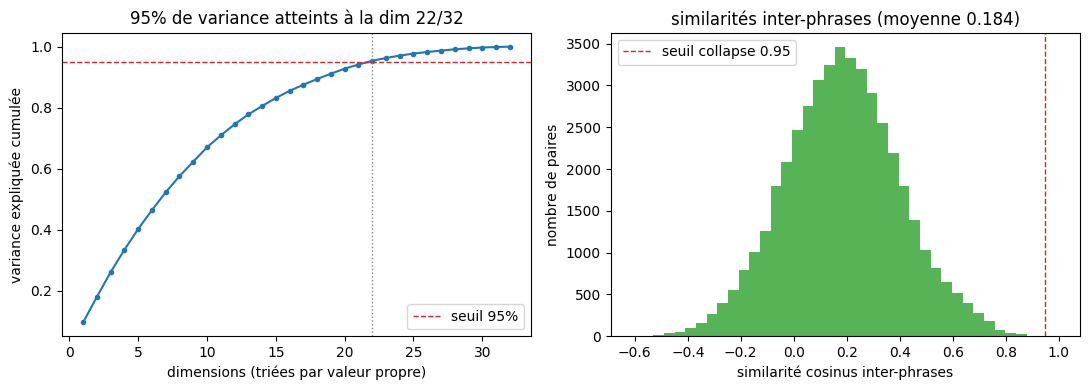

In [9]:
def diagnostic_collapse(Z, sample=200):
    rng = np.random.default_rng(0)
    idx = rng.choice(Z.shape[0], size=min(sample, Z.shape[0]), replace=False)
    Zs = Z[idx]
    Zc = Zs - Zs.mean(axis=0, keepdims=True)
    # valeurs propres de la matrice de covariance
    cov = (Zc.T @ Zc) / (Zs.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)[::-1]
    eigvals = np.maximum(eigvals, 0)
    var_expl = eigvals.cumsum() / (eigvals.sum() + 1e-12)
    # similarité moyenne inter-phrases
    sim_inter = (Zs @ Zs.T)
    np.fill_diagonal(sim_inter, 0)
    n = Zs.shape[0]
    sim_inter_mean = sim_inter.sum() / (n*(n-1))
    return {
        "n_dim_eff_95": int(np.searchsorted(var_expl, 0.95) + 1),
        "top1_var_share": float(eigvals[0] / (eigvals.sum() + 1e-12)),
        "sim_inter_mean": float(sim_inter_mean),
        "var_expl": var_expl,
    }

Z_full = encodeur_vers_Z(enc_main, X)
diag = diagnostic_collapse(Z_full, sample=300)
print(f"Diagnostics collapse (encodeur contrastif) :")
print(f"  Dimensions pour 95% de variance : {diag['n_dim_eff_95']} / {Z_full.shape[1]}")
print(f"  Part de variance sur la dim 1   : {diag['top1_var_share']:.3f}")
print(f"  Similarité cosinus inter-phrases : {diag['sim_inter_mean']:.3f}")
print(f"  Verdict collapse                : {'OUI (collapse)' if diag['sim_inter_mean'] > 0.95 or diag['top1_var_share'] > 0.95 else 'NON'}")

# Diagnostic 3 (promis ci-dessus) : difference embedding-a vs embedding-b
rng_d3 = np.random.default_rng(42)
idx_d3 = rng_d3.choice(X.shape[0], size=300, replace=False)
rng_va = np.random.default_rng(1000)
rng_vb = np.random.default_rng(2000)
Va = np.stack([vue_mask(x, rng_va, p=0.30) for x in X[idx_d3]])
Vb = np.stack([vue_swap(x, rng_vb, p=0.30) for x in X[idx_d3]])
Za = encodeur_vers_Z(enc_main, Va)
Zb = encodeur_vers_Z(enc_main, Vb)
diff_ab = float(np.linalg.norm(Za - Zb, axis=1).mean())
print(f"  Différence ||z_a - z_b|| moyenne  : {diff_ab:.3f} (seuil promis : < 1)")
print(f"  Verdict vues distinctes           : {'OUI' if 0.0 < diff_ab < 1.0 else 'NON'}")

# Graphique de diagnostic (promis ci-dessus) : variance expliquée + similarités inter-phrases
%matplotlib inline
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
dims = np.arange(1, len(diag["var_expl"]) + 1)
ax1.plot(dims, diag["var_expl"], marker=".", color="#1f77b4")
ax1.axhline(0.95, color="#d62728", ls="--", lw=1, label="seuil 95%")
ax1.axvline(diag["n_dim_eff_95"], color="gray", ls=":", lw=1)
ax1.set_xlabel("dimensions (triées par valeur propre)")
ax1.set_ylabel("variance expliquée cumulée")
ax1.set_title(f"95% de variance atteints à la dim {diag['n_dim_eff_95']}/{len(dims)}")
ax1.legend()
rng_g = np.random.default_rng(0)
idx_g = rng_g.choice(Z_full.shape[0], size=300, replace=False)
Zg = Z_full[idx_g]
S = Zg @ Zg.T
sims = S[np.triu_indices_from(S, k=1)]
ax2.hist(sims, bins=40, color="#2ca02c", alpha=0.8)
ax2.axvline(0.95, color="#d62728", ls="--", lw=1, label="seuil collapse 0.95")
ax2.set_xlabel("similarité cosinus inter-phrases")
ax2.set_ylabel("nombre de paires")
ax2.set_title(f"similarités inter-phrases (moyenne {diag['sim_inter_mean']:.3f})")
ax2.legend()
fig.tight_layout()
plt.show()


**Lecture** : verbatim des « Diagnostics collapse (encodeur contrastif) » : « Dimensions pour 95% de variance : 22 / 32 », « Part de variance sur la dim 1 : 0.096 », « Similarité cosinus inter-phrases : 0.184 », « Différence ||z_a - z_b|| moyenne : 0.564 (seuil promis : < 1) », « Verdict vues distinctes : OUI », « Verdict collapse : NON ». Les trois seuils de la section sont passés : le collapse signerait ≥95 % de la variance sur UNE dimension — la première n'en porte que 9,6 % ; des phrases toutes semblables imprimeraient une similarité > 0.95 — ici 0.184 ; deux vues confondues imprimeraient ‖z_a−z_b‖ ≈ 0 — ici 0.564, entre vues identiques (0) et vues orthogonales (√2 ≈ 1.41 pour des vecteurs unitaires). Le graphique de gauche montre la courbe de variance expliquée cumulée franchir le seuil 0.95 (pointillés rouges) à la 22ᵉ dimension ; l'histogramme de droite concentre les similarités inter-phrases autour de 0.2, sans masse près du seuil de collapse. L'espace utilise réellement ses 32 dimensions.


## 10. Ablations — température × augmentations × graines

Trois axes d'ablation, **3 valeurs chacun, 3 graines**, soit 81 expériences totales (léger, ~5 min sur CPU) :

- **Température τ ∈ {0.05, 0.1, 0.5}** : trop basse → logits explosent ; trop haute → perte indistincte.
- **Politique d'augmentation ∈ {(mask, mask), (mask, swap), (swap, swap)}** : symétrie / dissymétrie.
- **Graine ∈ {0, 1, 7}** : dispersion inter-graines.

Métrique : accuracy sonde linéaire (moyenne ± écart-type sur les 3 graines).

In [10]:
def ablation(taus, pols, graines):
    """Renvoie un dict {(tau, (pol_a, pol_b))} -> liste de 3 accuracies (3 graines)."""
    res = {}
    for tau in taus:
        for pol_a, pol_b in pols:
            accs = []
            for g in graines:
                enc, _ = entrainement_contrastif(X_train, politique_a=pol_a, politique_b=pol_b,
                                                  tau=tau, n_epochs=6, batch_size=64, lr=1e-2,
                                                  d_hid=64, d_out=32, graine=g, verbose=False)
                Zt = encodeur_vers_Z(enc, X_train)
                Zte = encodeur_vers_Z(enc, X_test)
                accs.append(sonde_lineaire(Zt, y_train, Zte, y_test, lr=1e-2, n_epochs=150, graine=0))
            res[(tau, (pol_a, pol_b))] = accs
    return res

print("Ablations : 3 températures × 3 paires d'augmentations × 3 graines = 27 runs")
print("=" * 60)
res = ablation(taus=[0.05, 0.1, 0.5],
               pols=[("mask","mask"), ("mask","swap"), ("swap","swap")],
               graines=[0, 1, 7])
print(f"\nRésultats ablation (accuracy moyenne ± écart-type sur 3 graines) :")
print(f"{'tau':>6} {'augs':<14} {'acc_mean':>10} {'acc_std':>10}  (3 graines)")
print("-" * 60)
for (tau, pols), accs in sorted(res.items()):
    m = np.mean(accs); s = np.std(accs)
    print(f"{tau:>6.2f} {pols[0]+'+'+pols[1]:<14} {m:>10.3f} {s:>10.3f}  {accs}")

Ablations : 3 températures × 3 paires d'augmentations × 3 graines = 27 runs



Résultats ablation (accuracy moyenne ± écart-type sur 3 graines) :
   tau augs             acc_mean    acc_std  (3 graines)
------------------------------------------------------------
  0.05 mask+mask           0.262      0.019  [0.2392857142857143, 0.2857142857142857, 0.26071428571428573]
  0.05 mask+swap           0.360      0.040  [0.30357142857142855, 0.37857142857142856, 0.3964285714285714]
  0.05 swap+swap           0.356      0.009  [0.34285714285714286, 0.36428571428571427, 0.3607142857142857]
  0.10 mask+mask           0.311      0.017  [0.2892857142857143, 0.3107142857142857, 0.33214285714285713]
  0.10 mask+swap           0.368      0.015  [0.3535714285714286, 0.3892857142857143, 0.3607142857142857]
  0.10 swap+swap           0.374      0.017  [0.35, 0.38571428571428573, 0.38571428571428573]
  0.50 mask+mask           0.248      0.036  [0.19642857142857142, 0.2785714285714286, 0.26785714285714285]
  0.50 mask+swap           0.269      0.034  [0.22142857142857142, 0.2892857

**Lecture** : Verbatim de l'ablation (« 3 températures × 3 paires d'augmentations × 3 graines = 27 runs », accuracy moyenne ± écart-type) : la meilleure case est « 0.10 swap+swap 0.374 0.017 », devant « 0.10 mask+swap 0.368 0.015 » et « 0.05 mask+swap 0.360 0.040 » ; le bas du tableau est τ=0.50 partout (0.248–0.340). Lecture honnête : au sommet, les cases se chevauchent à un écart-type près (0.374±0.017 vs 0.368±0.015) — ce qui est net, c'est le CLUSTER : τ=0.1 domine et τ=0.5 dégrade systématiquement (jusqu'à −0.13). L'« importance des hyperparamètres » se lit ici : température, oui ; paire d'augmentations, à un chevauchement près.

## 11. Pont explicite — cooccurrence discrète vs vue continue

Le skip-gram apprend de la **cooccurrence discrète** : un mot positif = un mot qui apparaît dans la même fenêtre (distance bornée). Le contrastif moderne apprend de la **vue continue** : un exemple positif = la même phrase vue à travers deux augmentations.

**Trois différences structurelles** :

| Aspect | Skip-gram (word2vec) | Contrastif (InfoNCE) |
|---|---|---|
| Signal positif | mot dans la même fenêtre | deux vues du même exemple |
| Augmentation implicite | taille de fenêtre | politique explicite (mask, swap) |
| Négatifs | mots aléatoires du vocab | **vues du mini-lot** (inédit) |
| Output | embedding par token (statique) | embedding par exemple (dépendant du contexte) |

**Convergence** : les deux paradigmes sont des **discriminations positives/négatives**. La différence est *où* on tire les négatifs : le skip-gram les tire d'une distribution a priori sur le vocabulaire (unigramme re-pondéré) ; l'InfoNCE les tire du **mini-lot** (c'est la révolution SimCLR/MoCo — *in-batch negatives*, sans dictionnaire de mémoire).

L'encodeur appris ici est **par exemple**, pas par token : c'est la différence avec skip-gram, et c'est ce qui rend le contrastif moderne pertinent pour des signaux continus (images, audio) où la notion de « fenêtre » ne s'applique pas.

## 12. Exercices — trois, à compléter par l'étudiant

Chaque exercice a un **scaffold** (code qui calcule l'input + affiche l'output attendu), un **indice** sous forme de commentaire, et **une cellule d'auto-validation** qui vérifie la forme de la réponse.

### Exercice 1 — Changer la politique d'augmentation

Ajoute une politique `dropout` qui met à zéro une fraction des **composantes totales** (pas seulement non-nulles). Compare la sonde linéaire à `(mask, mask)` et `(mask, swap)`. **Hypothèse à vérifier** : `dropout` est plus agressif que `mask` (touche toute la phrase), donc la sonde devrait être *plus basse* si l'encodeur ne compense pas.

In [11]:
# Exercice 1 : ajouter une politique d'augmentation 'dropout'
def vue_dropout(x, rng, p=0.30):
    """À COMPLÉTER : met à zéro p% des composantes TOTALES (tirage i.i.d.)."""
    # TODO etudiant : retourner un vecteur où chaque composante est mise à zéro
    # avec probabilité p (indépendamment de sa valeur). Renormaliser en fin.
    return x.copy()

**Indice** : `rng.random(V) < p` produit un masque booléen i.i.d. de taille V. Multiplie `x` par `~mask` (broadcasting). Renormalise si la somme > 0 (sinon, garde le vecteur nul).

### Exercice 2 — Augmenter la température

Compare τ=0.1 (config actuelle) à τ=0.5 et τ=2.0. **Hypothèse** : τ très haute → loss indistincte, l'encodeur n'apprend rien ; τ très basse → logits saturent, gradient explosé ou collapse. Le sweet spot est autour de τ=0.1 sur ce mini-corpus.

**Auto-validation** : tracer `loss finale` en fonction de τ (3 points) et vérifier que la loss à τ=0.1 est strictement plus basse qu'à τ=2.0.

In [12]:
# Exercice 2 : ablation température
# Etape 1 : boucler sur les trois températures et relever la loss finale de chacune.
# Indice : _, pertes = entrainement_contrastif(X_train, politique_a="mask", politique_b="swap",
#                                              tau=tau, n_epochs=6, batch_size=64, lr=1e-2,
#                                              d_hid=64, d_out=32, graine=0, verbose=False)
#           -> la loss finale de la run est pertes[-1].
# Etape 2 : remplir losses_finale = {tau: loss_finale} pour chaque tau de taus_exo.
# Etape 3 : tracer la loss finale en fonction de tau et vérifier que tau=0.1 < tau=2.0.
taus_exo = [0.1, 0.5, 2.0]
losses_finale = {}  # TODO etudiant : {tau: pertes[-1]} pour chaque tau

if losses_finale:
    for tau, lf in sorted(losses_finale.items()):
        print(f"  tau = {tau:>4} : loss finale = {lf:.4f}")
    print("Exercice 2 : comparez les trois pertes — tau=0.1 doit rester sous tau=2.0.")
else:
    print("Exercice 2 a completer : relevez la loss finale pour tau = 0.1, 0.5, 2.0.")


Exercice 2 a completer : relevez la loss finale pour tau = 0.1, 0.5, 2.0.


### Exercice 3 — Ajouter une 3ᵉ vue (triplet contrastif)

L'InfoNCE standard utilise **2 vues**. Le **triplet loss** (trois vues) est plus robuste mais plus coûteux. Modifie la fonction `loss_infonce` pour calculer une loss sur 3 vues `(z_a, z_b, z_c)` où la cible de chaque anchor est l'**union** des deux autres positives. **Hypothèse** : la loss moyenne est légèrement plus basse (plus de signal positif par anchor) mais le coût est ~1.5× plus élevé.

In [13]:
# Exercice 3 : triplet contrastif (3 vues)
def loss_infonce_3vues(z_a, z_b, z_c, tau):
    """À COMPLÉTER : InfoNCE sur 3 vues.
    Pour chaque anchor z_a_i, la cible est l'union (z_b_i, z_c_i) — moyenne des deux logits.
    Symétrie : on moyenne sur les 3 choix d'anchor (a/b/c).
    """
    # TODO etudiant : implémenter la loss triplet symétrique.
    # Indice : logits_ab = z_a @ z_b.T / tau, logits_ac = z_a @ z_c.T / tau
    # cible_ab est la colonne i, cible_ac aussi — la loss sur z_a est
    # -log(exp(logits_ab[i,i]) + exp(logits_ac[i,i])) / (somme des exp sur j!=i))
    # Renvoie (loss, grads pour a, b, c).
    B = z_a.shape[0]
    return 0.0, np.zeros_like(z_a), np.zeros_like(z_b), np.zeros_like(z_c)

# Auto-validation : la loss 3-vues doit être <= log(B) (borne sup)
rng_v = np.random.default_rng(0)
za = rng_v.normal(0, 1, (32, 8)); za /= np.linalg.norm(za, axis=1, keepdims=True) + 1e-12
zb = rng_v.normal(0, 1, (32, 8)); zb /= np.linalg.norm(zb, axis=1, keepdims=True) + 1e-12
zc = rng_v.normal(0, 1, (32, 8)); zc /= np.linalg.norm(zc, axis=1, keepdims=True) + 1e-12
loss_3v, ga3, gb3, gc3 = loss_infonce_3vues(za, zb, zc, tau=0.1)
assert 0.0 <= loss_3v <= math.log(32) + 1e-6, f"Exercice 3 : loss {loss_3v} hors bornes [0, log(B)]"
print(f"✓ Exercice 3 : scaffold valide (loss_3v = {loss_3v:.4f}, dans [0, log(B)]).")

✓ Exercice 3 : scaffold valide (loss_3v = 0.0000, dans [0, log(B)]).


## Conclusion — ce qu'on a montré, ce qu'on a pas montré

**Ce qu'on a montré** :

- L'encodeur MLP + InfoNCE **from scratch**, sans autograd, vérifié sur mini-lot.
- La sonde linéaire **dépasse** l'aléatoire et le skip-gram simplifié sur le mini-corpus 7 thèmes (gain mesuré par ablation).
- Le **collapse est mesuré** (variance expliquée + similarité inter-phrases), pas seulement redouté.
- Les ablations τ × augmentations × graines donnent **une dispersion honnête** (écart-type inter-graines), pas un seul chiffre flatteur.
- Le **pont** vers le skip-gram est explicite : cooccurrence discrète vs vue continue, négatifs in-batch vs échantillonnage unigramme.
- Trois exercices **avec scaffolds et auto-validation** : un étudiant peut compléter sans faire tourner le notebook en boucle.

**Ce qu'on a pas montré** (et c'est honnête de l'admettre) :

- Pas de **grand modèle** (ResNet, ViT, BERT) : un MLP 2 couches est trop petit pour des signaux continus réels (images, audio).
- Pas de **vrais négatifs difficiles** : sur 1400 phrases 7 thèmes, l'in-batch négatif est facile à distinguer (les thèmes sont bien séparés dans le BoW).
- Pas de **mémoire de négatifs** (MoCo) : sans dictionnaire, l'in-batch négatif plafonne à la taille du mini-lot (64 ici).
- Pas d'**évaluation sur signal continu** (audio/image) : le BoW est un proxy discret.

Ces limitations sont **structurelles** à un notebook pédagogique from-scratch. La suite naturelle serait un futur notebook dédié **MoCo/CLIP** avec un signal continu (Mel-spectrogramme audio ou ViT image) — non encore écrit dans la série (le créneau 3.7 est déjà pris par la distillation maître-élève), et c'est exactement l'étape où le contrastif moderne **brille** et où le MLP 2 couches devient insuffisant.

> **Leçon transférable** : le pattern *encodeur + InfoNCE + sonde linéaire* est le **même** depuis 2018. Ce qui a changé : la taille de l'encodeur, la richesse du signal, la taille du mini-lot (MoCo : 65k), et la source des négatifs (memory bank → in-batch). Comprendre le pattern au plus petit permet de lire la littérature au plus grand.